In [28]:
import pandas as pd
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import requests
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import stumpy
import numpy as np
from scipy.spatial.distance import cdist

import random

import matplotlib.cm as cm

from distancematrix import AnytimeCalculator
from distancematrix.consumer import MatrixProfileLR
from distancematrix.generator import ZNormEuclidean
from distancematrix.generator import Euclidean
from distancematrix.insights import highest_value_idxs, lowest_value_idxs


from scipy.sparse import lil_matrix, csr_matrix
import matplotlib.ticker as mticker

In [6]:
VIRTUOSO_URL = "http://localhost:8890/sparql"
GRAPH_URI    = "http://example.com/Gent-Terneuzen"
USERNAME     = "dba"
PASSWORD     = "dba"
AUTH         = (USERNAME, PASSWORD)

In [7]:
params  = {'graph': GRAPH_URI}
headers = {'Accept': 'text/turtle'}

# Identifying unique sensors


In [8]:
sensor_set = set()

sensor_query = f"""
    PREFIX sosa: <http://www.w3.org/ns/sosa/>
    SELECT DISTINCT ?sensor
    WHERE {{
        GRAPH <{GRAPH_URI}> {{
            ?obs a sosa:Observation ;
                 sosa:madeBySensor ?sensor .
        }}
    }}
    """
res = requests.get(VIRTUOSO_URL, params={'query': sensor_query, 'format': 'application/sparql-results+json'})
if res.status_code != 200:
    print(f"Error: {res.status_code}")
    print("Response:", res.text)
else:
    print("Unique sensors identified successfully!")

data     = res.json()
bindings = data['results']['bindings']
for row in bindings:
    sensor_set.add(row['sensor']['value'])

print(f"Added {len(sensor_set)} unique sensors to the set.")
print("Sensors:", sensor_set)

Unique sensors identified successfully!
Added 4 unique sensors to the set.
Sensors: {'http://example.com/waterinfo/289441042', 'http://example.com/waterinfo/289423042', 'http://example.com/waterinfo/289435042', 'http://example.com/waterinfo/289429042'}


# Reframe the data

In [9]:
final_df = pd.DataFrame()
print("Fetching and pivoting sensor data...")

for sensor_uri in sensor_set:
    column_name = sensor_uri.split('/')[-1]
    query = f"""
        PREFIX sosa: <http://www.w3.org/ns/sosa/>
        PREFIX ex: <http://example.com/attributes/>
        SELECT ?time ?value ?unixtime
        WHERE {{
            GRAPH <{GRAPH_URI}> {{
                ?obs a sosa:Observation ;
                    sosa:resultTime ?time ;
                    sosa:hasSimpleResult ?value ;
                    ex:unixTimestamp ?unixtime ;
                    sosa:madeBySensor <{sensor_uri}> .
            }}
        }}
    """
    res = requests.get(VIRTUOSO_URL, params={'query': query, 'format': 'application/sparql-results+json'})
    if res.status_code == 200:
        bindings = res.json()['results']['bindings']
        temp_data = [
            {'time': row['time']['value'], column_name: float(row['value']['value']),
             'unixtime': int(row['unixtime']['value'])}
            for row in bindings
        ]
        temp_df = pd.DataFrame(temp_data)
        if not temp_df.empty:
            temp_df['time'] = pd.to_datetime(temp_df['time'])
            if final_df.empty:
                final_df = temp_df
            else:
                final_df = pd.merge(final_df, temp_df, on=['time', 'unixtime'], how='outer')
            print(f"Added column for sensor: {column_name}")

final_df = final_df.sort_values('time').set_index('time')
print("Finished!")
print(final_df.head())

Fetching and pivoting sensor data...
Added column for sensor: 289441042
Added column for sensor: 289423042
Added column for sensor: 289435042
Added column for sensor: 289429042
Finished!
                           289441042    unixtime  289423042  289435042  \
time                                                                     
2021-03-03 23:15:00+00:00    4797.72  1614813300        NaN    3606.54   
2021-03-03 23:30:00+00:00    4717.80  1614814200        NaN        NaN   
2021-03-03 23:45:00+00:00    4745.36  1614815100     902.27    3556.45   
2021-03-04 00:00:00+00:00        NaN  1614816000        NaN        NaN   
2021-03-04 00:15:00+00:00        NaN  1614816900     901.96        NaN   

                           289429042  
time                                  
2021-03-03 23:15:00+00:00    1605.77  
2021-03-03 23:30:00+00:00        NaN  
2021-03-03 23:45:00+00:00    1602.34  
2021-03-04 00:00:00+00:00    1611.26  
2021-03-04 00:15:00+00:00    1614.24  


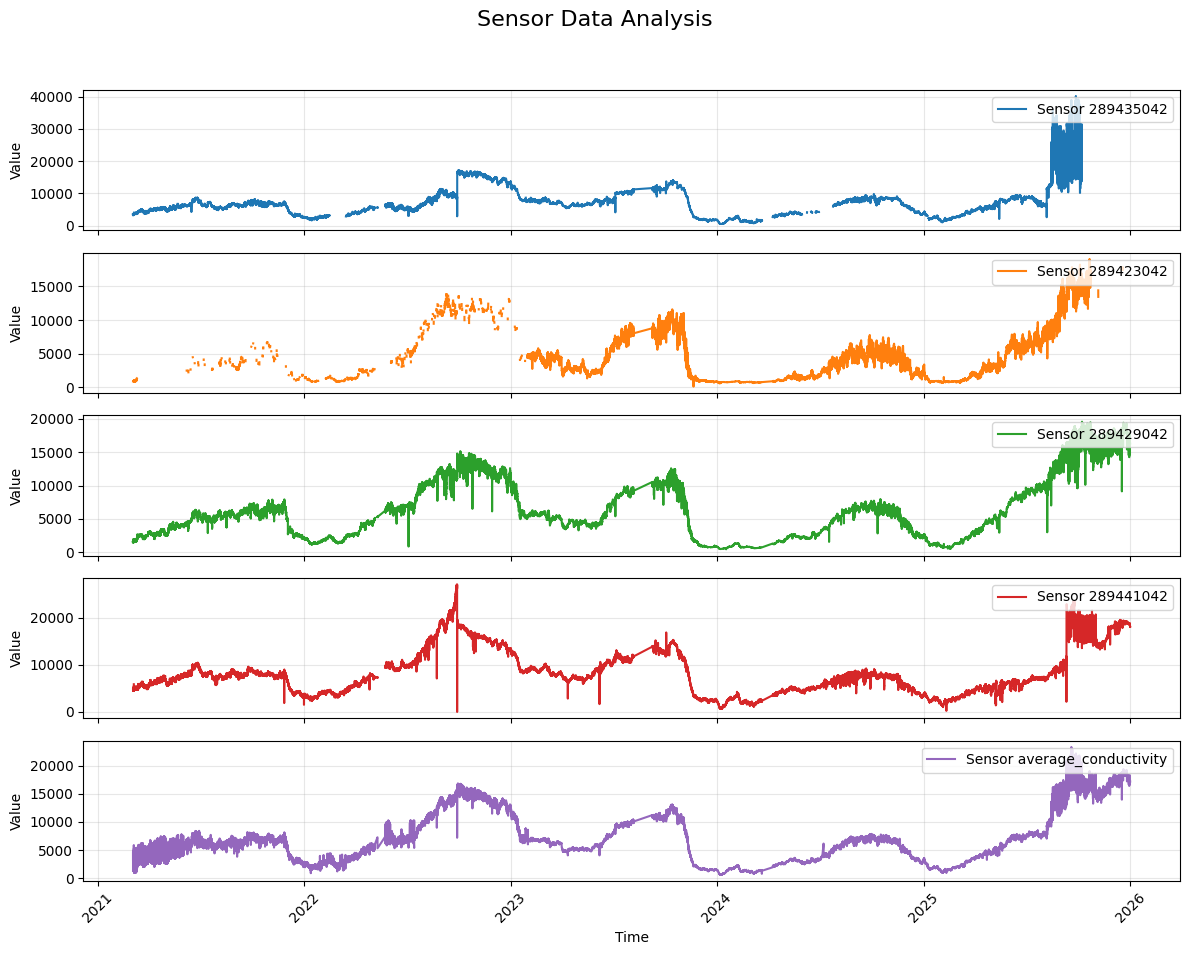

In [10]:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 10), sharex=True)

sensors = ['289435042', '289423042', '289429042', '289441042']
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728','#9467bd']
final_df['average_conductivity'] = final_df[sensors].mean(axis=1)
sensors_with_avg = sensors + ['average_conductivity']

for i, sensor in enumerate(sensors_with_avg):
    ax = axes[i]
    ax.plot(final_df.index, final_df[sensor], label=f"Sensor {sensor}", color=colors[i])
    ax.set_ylabel("Value")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("Sensor Data Analysis", fontsize=16)
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Feature Engineering

In [11]:
data = final_df.copy()
target_sensor = '289441042'

# 1. Time-based features (Seasonality)
data['hour'] = data.index.hour
data['day_of_week'] = data.index.dayofweek
data['month'] = data.index.month


# 2. Lag features for the TARGET (Sensor 4)
    # We look back 15m, 1h, and 24h
for lag in [1, 4, 96,672, 2880]:
    data[f'{target_sensor}_lag_{lag}'] = data[target_sensor].shift(lag)

# 3. Spatial Lag features for NEIGHBORS (Sensors 1, 2, 3)
# These provide "upstream" context
neighbors = [c for c in final_df.columns if c != target_sensor]

for s in neighbors:
        data[f'{s}_lag_1'] = data[s].shift(1)  # What happened 15 mins ago upstream?
        data[f'{s}_lag_4'] = data[s].shift(4)  # What happened 1 hour ago upstream?
        data[f'{s}_lag_672']  = data[s].shift(672)   # 1 week ago upstream
        data[f'{s}_lag_2880'] = data[s].shift(2880)
        data[f'{s}_roc_1']  = data[s].diff(1)   # upstream rate of change
        data[f'{s}_roc_4']  = data[s].diff(4)   # upstream hourly change
        data[f'{s}_roc_672']  = data[s].diff(672)   # upstream weekly change
        data[f'{s}_roc_2880'] = data[s].diff(2880)  # upstream monthly change

# 4. Rolling statistics (Trend)
data['rolling_mean_6h'] = data[target_sensor].shift(1).rolling(window=24).mean()

# In Cell 9, after rolling_mean_6h:

# Rate of change (is the signal rising or falling fast?)
data['roc_1']  = data[target_sensor].diff(1)   # 15-min change
data['roc_4']  = data[target_sensor].diff(4)   # 1-hour change
data['roc_96'] = data[target_sensor].diff(96)  # 24-hour change

# Volatility (is the signal stable or jumping around?)
data['rolling_std_6h']  = data[target_sensor].shift(1).rolling(window=24).std()
data['rolling_std_24h'] = data[target_sensor].shift(1).rolling(window=96).std()

# Rolling min/max (captures the range of recent behaviour)
data['rolling_max_24h'] = data[target_sensor].shift(1).rolling(window=96).max()
data['rolling_min_24h'] = data[target_sensor].shift(1).rolling(window=96).min()


data.dropna(inplace=True)
df_featured = data.copy()
print(f"df_featured shape: {df_featured.shape}")
print(f"Date range: {df_featured.index.min()} → {df_featured.index.max()}")

df_featured shape: (75402, 62)
Date range: 2023-02-06 14:00:00+00:00 → 2025-10-07 07:30:00+00:00


# Data preparation

In [12]:
# Split based on your specific dates
train_data = df_featured[:'2025-07-31'] # all data up to July 2025
test_data = df_featured['2025-07-01':'2025-07-30'] # ground truth month



X_train = train_data.drop(columns=sensors)  # Drop original sensor columns
y_train = train_data[target_sensor]

X_test = test_data.drop(columns=sensors)
y_test = test_data[target_sensor]

# Does the data contain high conductivity events? 
print("Train conductivity range:", y_train.min(), "→", y_train.max())
print("Test  conductivity range:", y_test.min(),  "→", y_test.max())

Train conductivity range: 226.79 → 16851.66
Test  conductivity range: 6074.92 → 7693.67


In [13]:
# Sanity check
# #print("Training data shape:", X_train.shape)
# print("Testing data shape:", X_test.shape)
# #print(X_train.head())
# print(X_test.head())



# Actual training 

In [14]:
model = lgb.LGBMRegressor(
    n_estimators=5000,      # Increased: More trees for better learning
    learning_rate=0.01,     # Decreased: Slower, more precise learning
    num_leaves=128,         # Increased: Allows for more complex patterns
    max_depth=12,           # Limited: Prevents the trees from growing too deep
    min_data_in_leaf=50,   # Regularization: Prevents overfitting to noise (lower = more sensitive)
    feature_fraction=0.8,   # Generalization: Don't rely on all sensors at once
    n_jobs=-1,
    subsample=0.8,          # ADD: row subsampling for better generalisation
    reg_alpha=0.1,          # ADD: L1 regularisation
    reg_lambda=0.1,         # ADD: L2 regularisation
)

# Use early stopping to find the perfect n_estimators automatically
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=100)] 
)

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005947 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13078
[LightGBM] [Info] Number of data points in the train set: 69041, number of used features: 56
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current 

,boosting_type,'gbdt'
,num_leaves,128
,max_depth,12
,learning_rate,0.01
,n_estimators,5000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# Forecast and Compare

In [15]:
forecast = model.predict(X_test)
mae = mean_absolute_error(y_test, forecast)
print(f"September 2025 Forecast MAE: {mae:.4f} units of conductivity")

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
September 2025 Forecast MAE: 8.3580 units of conductivity


# Bias check

In [16]:
error = y_test - forecast
print(f"Mean Error (Bias): {error.mean()}")

# positive bias means we are underpredicting on average, negative bias means we are overpredicting on average.

Mean Error (Bias): 0.12759168118862535


# Visualizing truth vs prediction

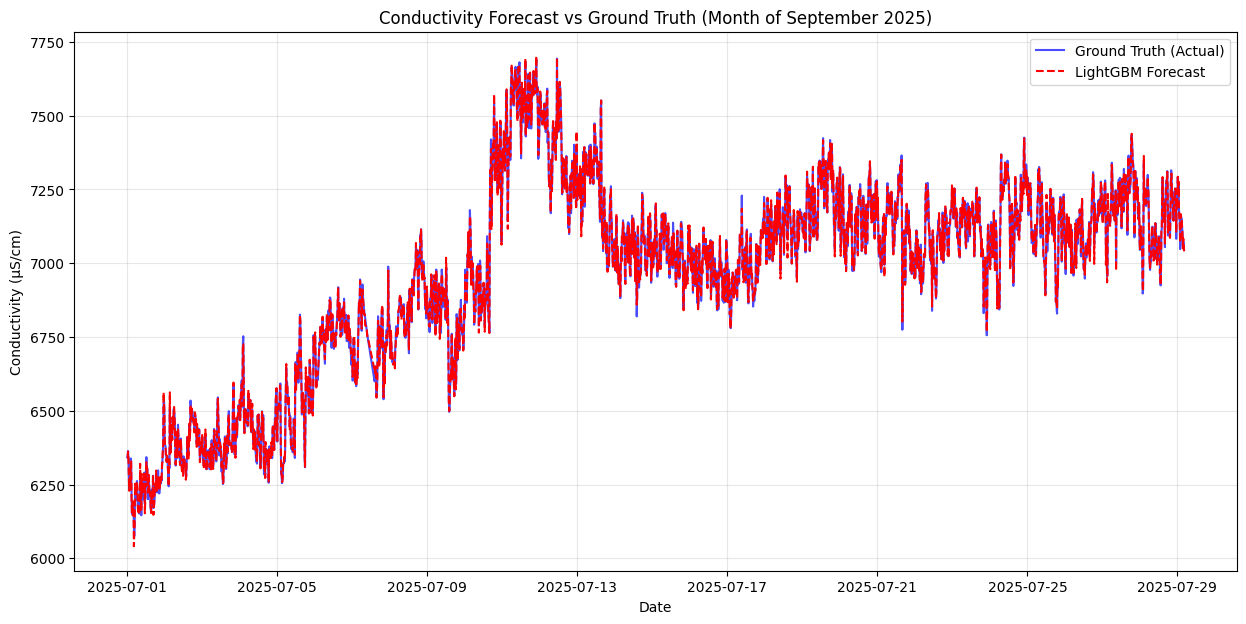

In [17]:
# 1. Create a DataFrame for easy plotting
results = pd.DataFrame({
    'Actual': y_test,
    'Forecast': forecast
}, index=y_test.index)

# 2. Plotting a 7-day window to see the detail
plt.figure(figsize=(15, 7))
plt.plot(results['Actual'].iloc[:2688], label='Ground Truth (Actual)', color='blue', alpha=0.7)
# 672 rows = 7 days * 24 hours * 4 readings/hour
plt.plot(results['Forecast'].iloc[:2688], label='LightGBM Forecast', color='red', linestyle='--')

plt.title('Conductivity Forecast vs Ground Truth (Month of September 2025)')
plt.xlabel('Date')
plt.ylabel('Conductivity (μS/cm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## The model is really good in predicting a week in the future. Any more than that and it falls of quite quickly

# XGBoost

In [18]:
# 1. Convert your data into XGBoost's optimized format (DMatrix)
# Note: You use the same X_train, y_train we created for LightGBM
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [19]:
params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'eta': 0.01,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'colsample_bylevel': 0.8,       # ADD: also subsample per tree depth level
    'min_child_weight': 10,         # ADD: min sum of instance weight in a leaf (like min_data_in_leaf in LightGBM)
    'gamma': 0.1,                   # ADD: min loss reduction required to split (0 = no constraint)
    'alpha': 0.1,                   # ADD: L1 regularisation on weights
    'lambda': 1.5,                  # ADD: L2 regularisation on weights (default is 1)
    'eval_metric': ['rmse', 'mae'], # CHANGE: watch both so you can see error shape
    'seed': 42,                     # ADD: reproducibility
}

evallist = [(dtrain, 'train'), (dtest, 'eval')]

# ADD: verbose_eval so you only print every 100 rounds instead of every round
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=5000,           # CHANGE: give it more headroom, early stopping will cut it short
    evals=evallist,
    early_stopping_rounds=100,      # CHANGE: 50 is too aggressive at lr=0.01, use 100
    verbose_eval=100,               # ADD: only log every 100 rounds
)

print(f"Best iteration : {bst.best_iteration}")
print(f"Best eval MAE  : {bst.best_score:.4f}")

predictions_xgb = bst.predict(dtest, iteration_range=(0, bst.best_iteration)) # XGBoost doesn't automatically use best_iteration on predict. Without this, it uses ALL trees including the ones after the best checkpoint.

[0]	train-rmse:3321.74148	train-mae:2711.50298	eval-rmse:802.55466	eval-mae:737.39563
[100]	train-rmse:1222.46792	train-mae:997.56959	eval-rmse:298.83101	eval-mae:271.54524
[200]	train-rmse:454.34230	train-mae:369.55755	eval-rmse:117.10796	eval-mae:102.70663
[300]	train-rmse:174.84780	train-mae:139.01010	eval-rmse:51.75197	eval-mae:43.26202
[400]	train-rmse:76.29533	train-mae:54.83343	eval-rmse:28.05799	eval-mae:22.50299
[500]	train-rmse:44.71531	train-mae:25.92467	eval-rmse:19.56311	eval-mae:15.02287
[600]	train-rmse:35.21249	train-mae:17.83223	eval-rmse:16.34046	eval-mae:12.26776
[700]	train-rmse:31.39953	train-mae:15.75164	eval-rmse:14.98978	eval-mae:11.15942
[800]	train-rmse:28.75493	train-mae:14.95749	eval-rmse:14.19842	eval-mae:10.57993
[900]	train-rmse:26.91791	train-mae:14.51286	eval-rmse:13.79376	eval-mae:10.31159
[1000]	train-rmse:25.52478	train-mae:14.21822	eval-rmse:13.55512	eval-mae:10.18157
[1100]	train-rmse:24.47169	train-mae:13.99115	eval-rmse:13.36870	eval-mae:10.08936

# Compare

In [20]:
mae_xgb = mean_absolute_error(y_test, predictions_xgb)
print(f"XGBoost  MAE: {mae_xgb:.4f}")

XGBoost  MAE: 7.6639


# Visualization

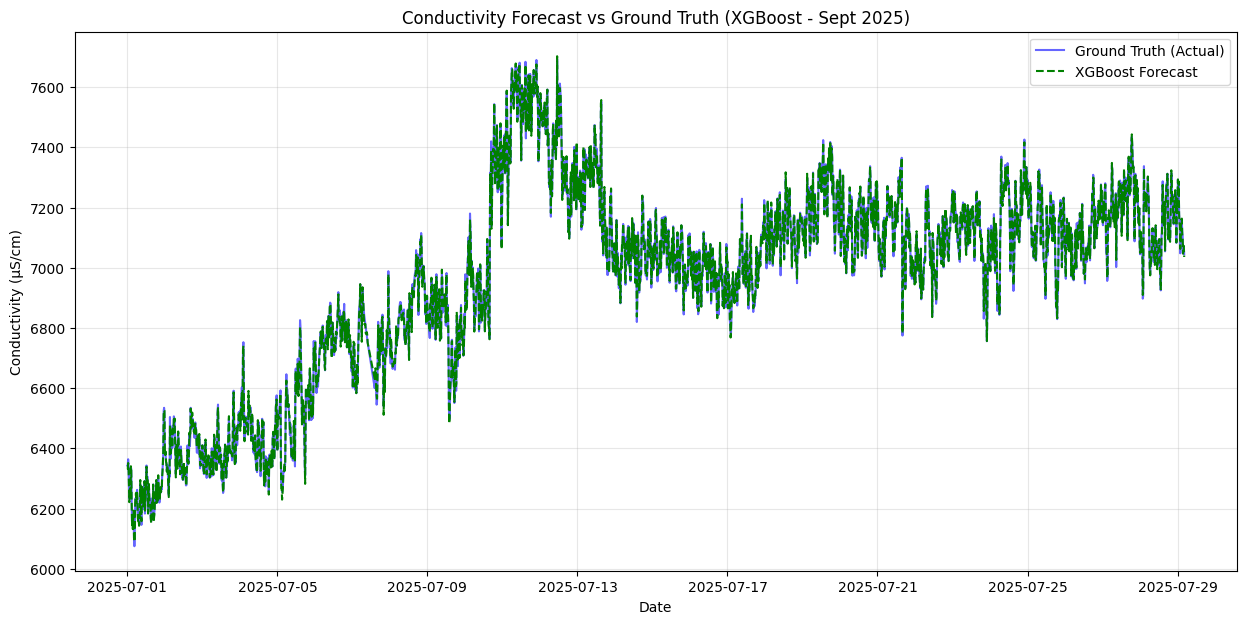

In [21]:

# 1. Create a DataFrame for XGBoost results
# Ensure 'predictions_xgb' is the output from bst.predict(dtest)
results_xgb = pd.DataFrame({
    'Actual': y_test,
    'XGBoost_Forecast': predictions_xgb
}, index=y_test.index)

# 2. Plotting the 28-day window (2688 rows)
plt.figure(figsize=(15, 7))

# Plot Actual Data
plt.plot(results_xgb['Actual'].iloc[:2688], 
         label='Ground Truth (Actual)', 
         color='blue', 
         alpha=0.6)

# Plot XGBoost Forecast
plt.plot(results_xgb['XGBoost_Forecast'].iloc[:2688], 
         label='XGBoost Forecast', 
         color='green',           # Using Green to distinguish from LightGBM's Red
         linestyle='--', 
         linewidth=1.5)

plt.title('Conductivity Forecast vs Ground Truth (XGBoost - Sept 2025)')
plt.xlabel('Date')
plt.ylabel('Conductivity (μS/cm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Head to head comparison of forecasts

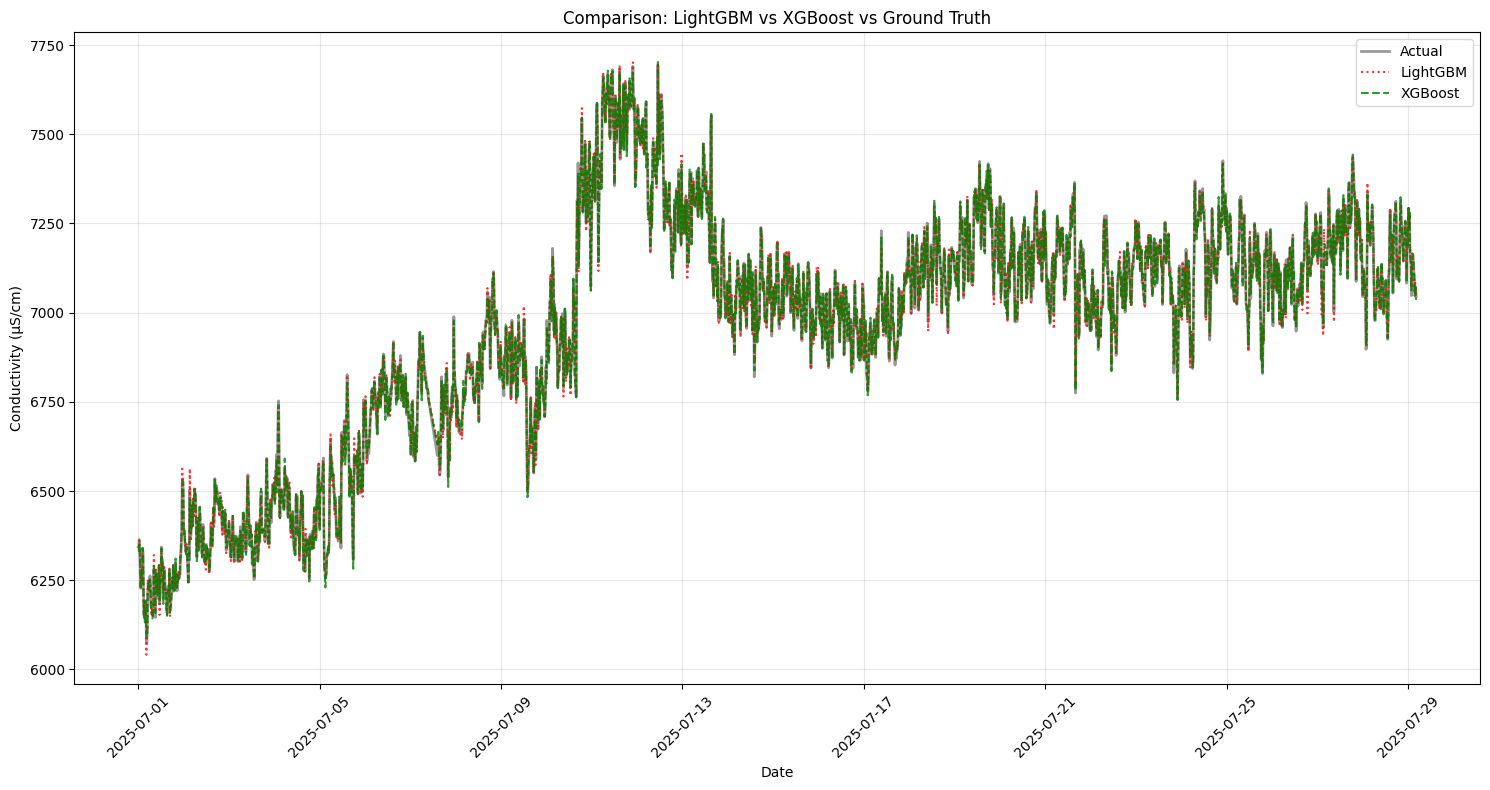

In [22]:
# Head to head comparison
comparison = pd.DataFrame({
    'Actual':   y_test.values[:2688],
    'LightGBM': forecast[:2688],
    'XGBoost':  predictions_xgb[:2688]
}, index=y_test.index[:2688])

plt.figure(figsize=(15, 8))
plt.plot(comparison['Actual'],   label='Actual',    color='black', alpha=0.4, linewidth=2)
plt.plot(comparison['LightGBM'], label='LightGBM',  color='red',   linestyle=':',  alpha=0.8)
plt.plot(comparison['XGBoost'],  label='XGBoost',   color='green', linestyle='--', alpha=0.8)

plt.title('Comparison: LightGBM vs XGBoost vs Ground Truth')
plt.xlabel('Date')
plt.ylabel('Conductivity (μS/cm)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Ensemble

In [23]:
final_ensemble = (forecast + predictions_xgb) / 2

mae_ensemble = mean_absolute_error(y_test, final_ensemble)
print(f"Final Ensemble MAE: {mae_ensemble:.4f}")

Final Ensemble MAE: 5.9970


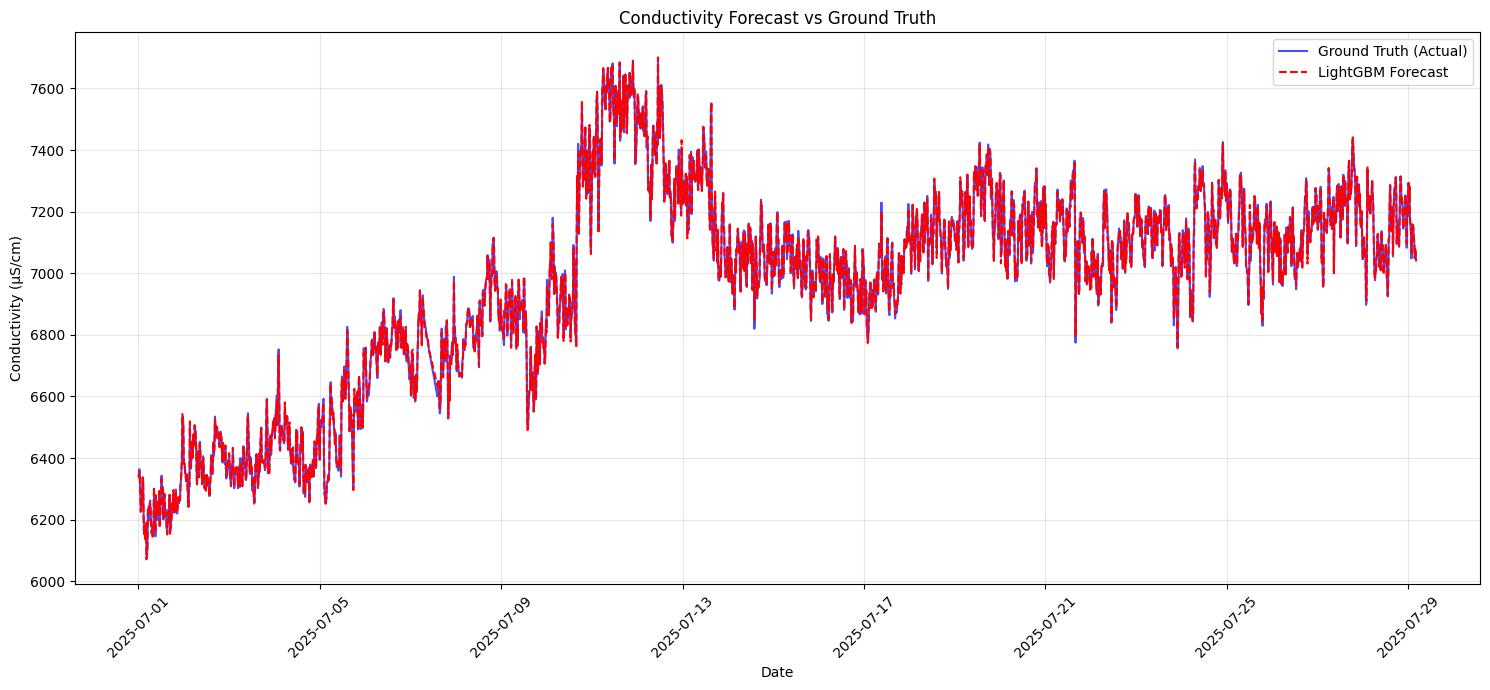

In [24]:
results = pd.DataFrame({
    'Actual':   y_test.values[:2688],
    'Forecast': final_ensemble[:2688]
}, index=y_test.index[:2688])

plt.figure(figsize=(15, 7))
plt.plot(results['Actual'],   label='Ground Truth (Actual)', color='blue', alpha=0.7)
plt.plot(results['Forecast'], label='LightGBM Forecast',     color='red',  linestyle='--')

plt.title('Conductivity Forecast vs Ground Truth')
plt.xlabel('Date')
plt.ylabel('Conductivity (μS/cm)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Matrix profile

In [25]:
# STUMPY doesn't handle NaNs, so we interpolate missing values
signal = final_df['average_conductivity'].interpolate(method='linear').bfill().ffill().values
# 96 periods * 15 mins = 24 hours. 8640 = 3 months (season). 2880 = 1 month
m = 96*7
# Compute the matrix profile
mp = stumpy.stump(signal, m)
#Find the Motif (most repeated pattern) and Discord (biggest anomaly)
# 1. Choose how many you want to find
top_n = 5
# Exclusion zone: once we find a motif/discord, skip 'm' points so we don't pick the same event twice
exclusion_zone = m 

# --- MULTIPLE DISCORDS (Top Peaks) ---
# We sort indices by distance in descending order (highest first)
sorted_indices = np.argsort(mp[:, 0])[::-1]
discords = []
for idx in sorted_indices:
    if len(discords) >= top_n:
        break
    # Check if this index is far enough away from already found discords
    if all(abs(idx - d) > exclusion_zone for d in discords):
        discords.append(idx)

# --- MULTIPLE MOTIFS (Lowest Valleys) ---
# We sort indices by distance in ascending order (lowest first)
sorted_indices = np.argsort(mp[:, 0])
motifs = []
for idx in sorted_indices:
    if len(motifs) >= top_n:
        break
    if all(abs(idx - m_idx) > exclusion_zone for m_idx in motifs):
        motifs.append(idx)

# Print results
print(f"Top {top_n} Discord indices:", discords)
print(f"Top {top_n} Motif indices:", motifs)

Top 5 Discord indices: [np.int64(1012), np.int64(2990), np.int64(4110), np.int64(17079), np.int64(1685)]
Top 5 Motif indices: [np.int64(88198), np.int64(96444), np.int64(92893), np.int64(69505), np.int64(95654)]


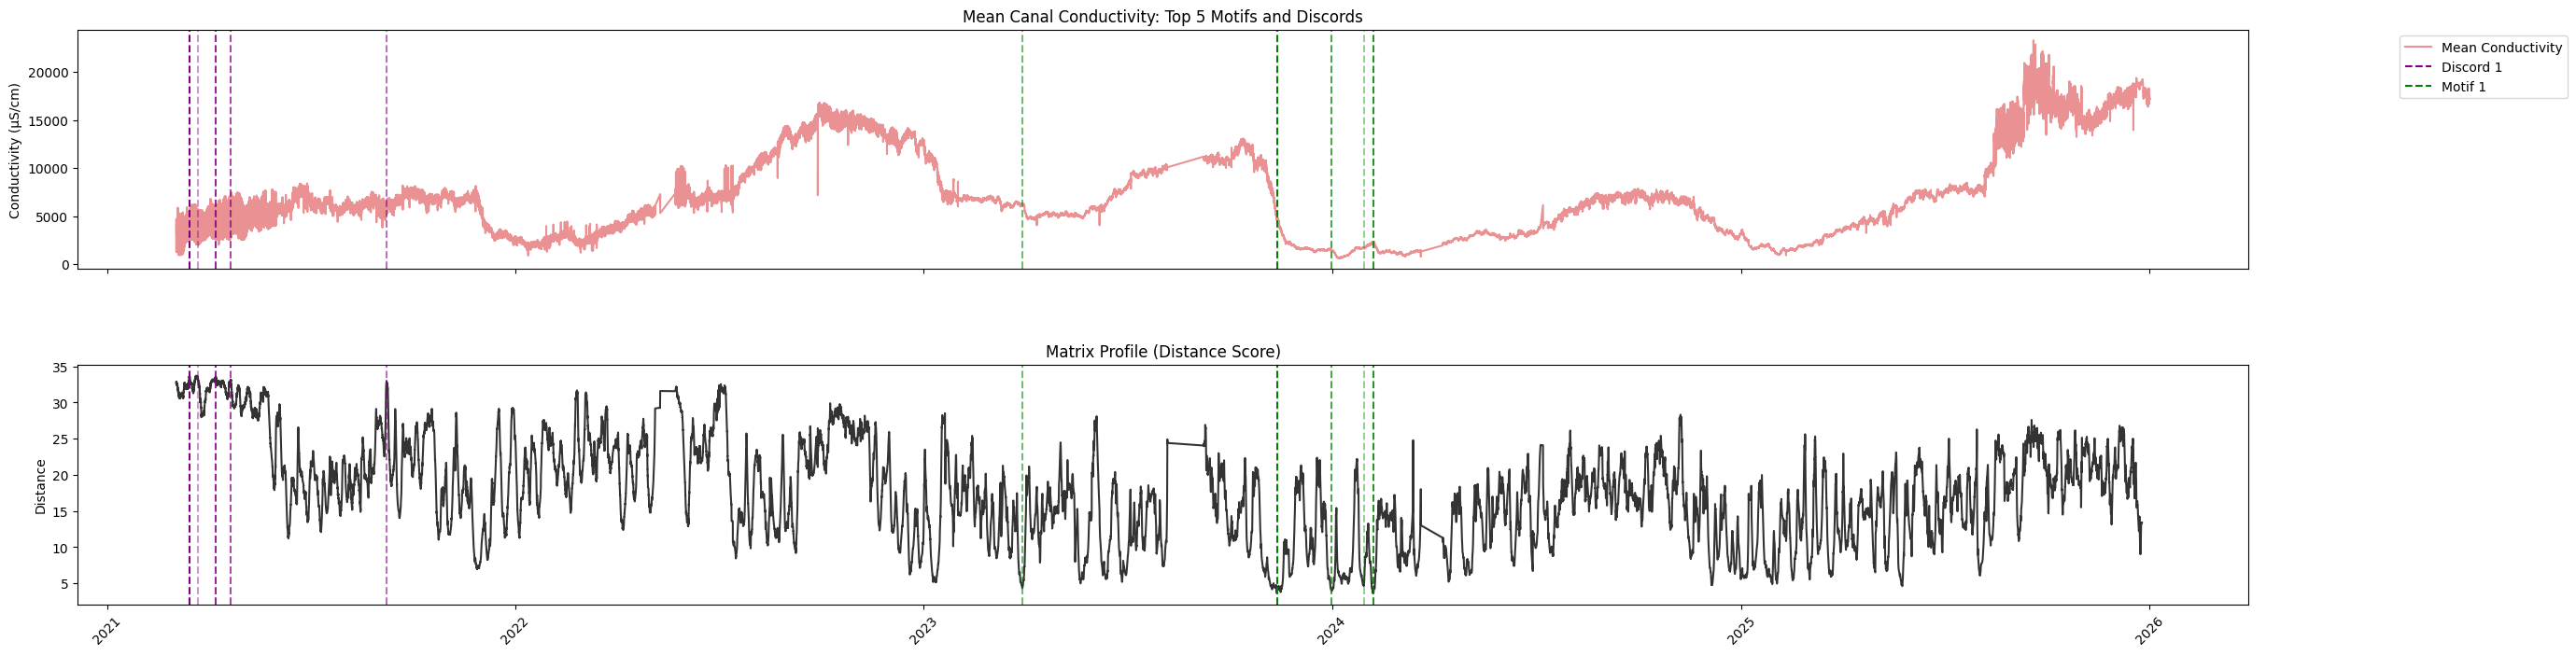

In [26]:
# Choose how many you want to display (matches the lists from the previous step)
n_to_plot = 5 

# Visualization
fig, axs = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0.4}, figsize=(30, 8))

# 1. TOP PLOT: Raw Signal (Average Conductivity)
axs[0].plot(final_df.index, signal, color='#d62728', alpha=0.5, label='Mean Conductivity')
axs[0].set_title(f'Mean Canal Conductivity: Top {n_to_plot} Motifs and Discords')
axs[0].set_ylabel('Conductivity (μS/cm)')

# 2. BOTTOM PLOT: Matrix Profile
axs[1].plot(final_df.index[:len(mp)], mp[:, 0], color='black', alpha=0.8)
axs[1].set_title('Matrix Profile (Distance Score)')
axs[1].set_ylabel('Distance')

# 3. LOOP TO ADD MULTIPLE LINES
# Using 'Purples' for discords and 'Greens' for motifs
for i in range(len(discords)):
    alpha_val = 1.0 - (i * 0.15) # Make the top discord darker than the others
    axs[0].axvline(x=final_df.index[discords[i]], color='purple', linestyle='--', alpha=alpha_val, label=f'Discord {i+1}' if i==0 else "")
    axs[1].axvline(x=final_df.index[discords[i]], color='purple', linestyle='--', alpha=alpha_val)

for i in range(len(motifs)):
    alpha_val = 1.0 - (i * 0.15)
    axs[0].axvline(x=final_df.index[motifs[i]], color='green', linestyle='--', alpha=alpha_val, label=f'Motif {i+1}' if i==0 else "")
    axs[1].axvline(x=final_df.index[motifs[i]], color='green', linestyle='--', alpha=alpha_val)

axs[0].legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.xticks(rotation=45)
plt.show()

# Multi dimension Matrix Profile

In [ ]:
# ── 1. Prepare multidimensional signal (sensors as rows) ──────────────────────
sensors = ['289435042', '289423042', '289429042', '289441042']

# mstump expects shape (n_dimensions, n_timepoints)
T = np.array([
    final_df[s].interpolate(method='linear').bfill().ffill().values
    for s in sensors
]) #Stacks the 4 sensor time series into a 2D array

m = 96 * 7  # 1-week window

# ── 2. Compute Multidimensional Matrix Profile ────────────────────────────────
# Returns:
#   mmp  : shape (n_dims, n - m + 1) — distance profile per dimensionality
#   mmp_I: shape (n_dims, n - m + 1) — nearest neighbor index per dimensionality
mmp, mmp_I = stumpy.mstump(T, m)

# ── 3. Find Motifs and Discords per dimensionality level ─────────────────────
# Row 0 = best 1-D match, Row 1 = best 2-D match, etc.
top_n        = 3
exclusion_zone = m

def find_peaks(profile, top_n, exclusion_zone, ascending=True):
    order = np.argsort(profile) if ascending else np.argsort(profile)[::-1]
    found = []
    for idx in order:
        if len(found) >= top_n:
            break
        if all(abs(idx - f) > exclusion_zone for f in found):
            found.append(int(idx))
    return found

# Use the last row (all dimensions combined) as the aggregate profile
aggregate_profile = mmp[-1]  # shape: (n - m + 1,)

motifs   = find_peaks(aggregate_profile, top_n, exclusion_zone, ascending=True)
discords = find_peaks(aggregate_profile, top_n, exclusion_zone, ascending=False)

time_index = final_df.index  # DatetimeIndex

# ── 4. Build the 2D Distance Matrix for heatmap ──────────────────────────────
# For each pair of subsequences (i, j), distance = aggregate_profile at i
# We approximate the full NxN matrix using the nearest-neighbor indices
n_subseq = mmp.shape[1]

# ── 4. Build SPARSE distance matrix (only fills known NN pairs) ───────────────
# lil_matrix is efficient for incremental insertion
dist_sparse = lil_matrix((n_subseq, n_subseq), dtype=np.float32)  # float32 halves memory vs float64

for i in range(n_subseq):
    j = int(mmp_I[-1, i])
    d = float(aggregate_profile[i])
    dist_sparse[i, j] = d
    dist_sparse[j, i] = d

dist_sparse = dist_sparse.tocsr()  # convert to CSR for fast row slicing

# ── 5. Downsample for heatmap rendering ──────────────────────────────────────
# Never try to render 160k x 160k — sample down to ~500 x 500
target_size = 500
step = max(1, n_subseq // target_size)
sample_idx  = np.arange(0, n_subseq, step)

# Extract the sampled submatrix as dense (500x500 = trivial memory)
ds = dist_sparse[sample_idx, :][:, sample_idx].toarray()

# Replace zeros (unfilled) with NaN for cleaner visualization
ds[ds == 0] = np.nan




C:\Users\AYMANS\AppData\Local\Temp\ipykernel_7844\163839953.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


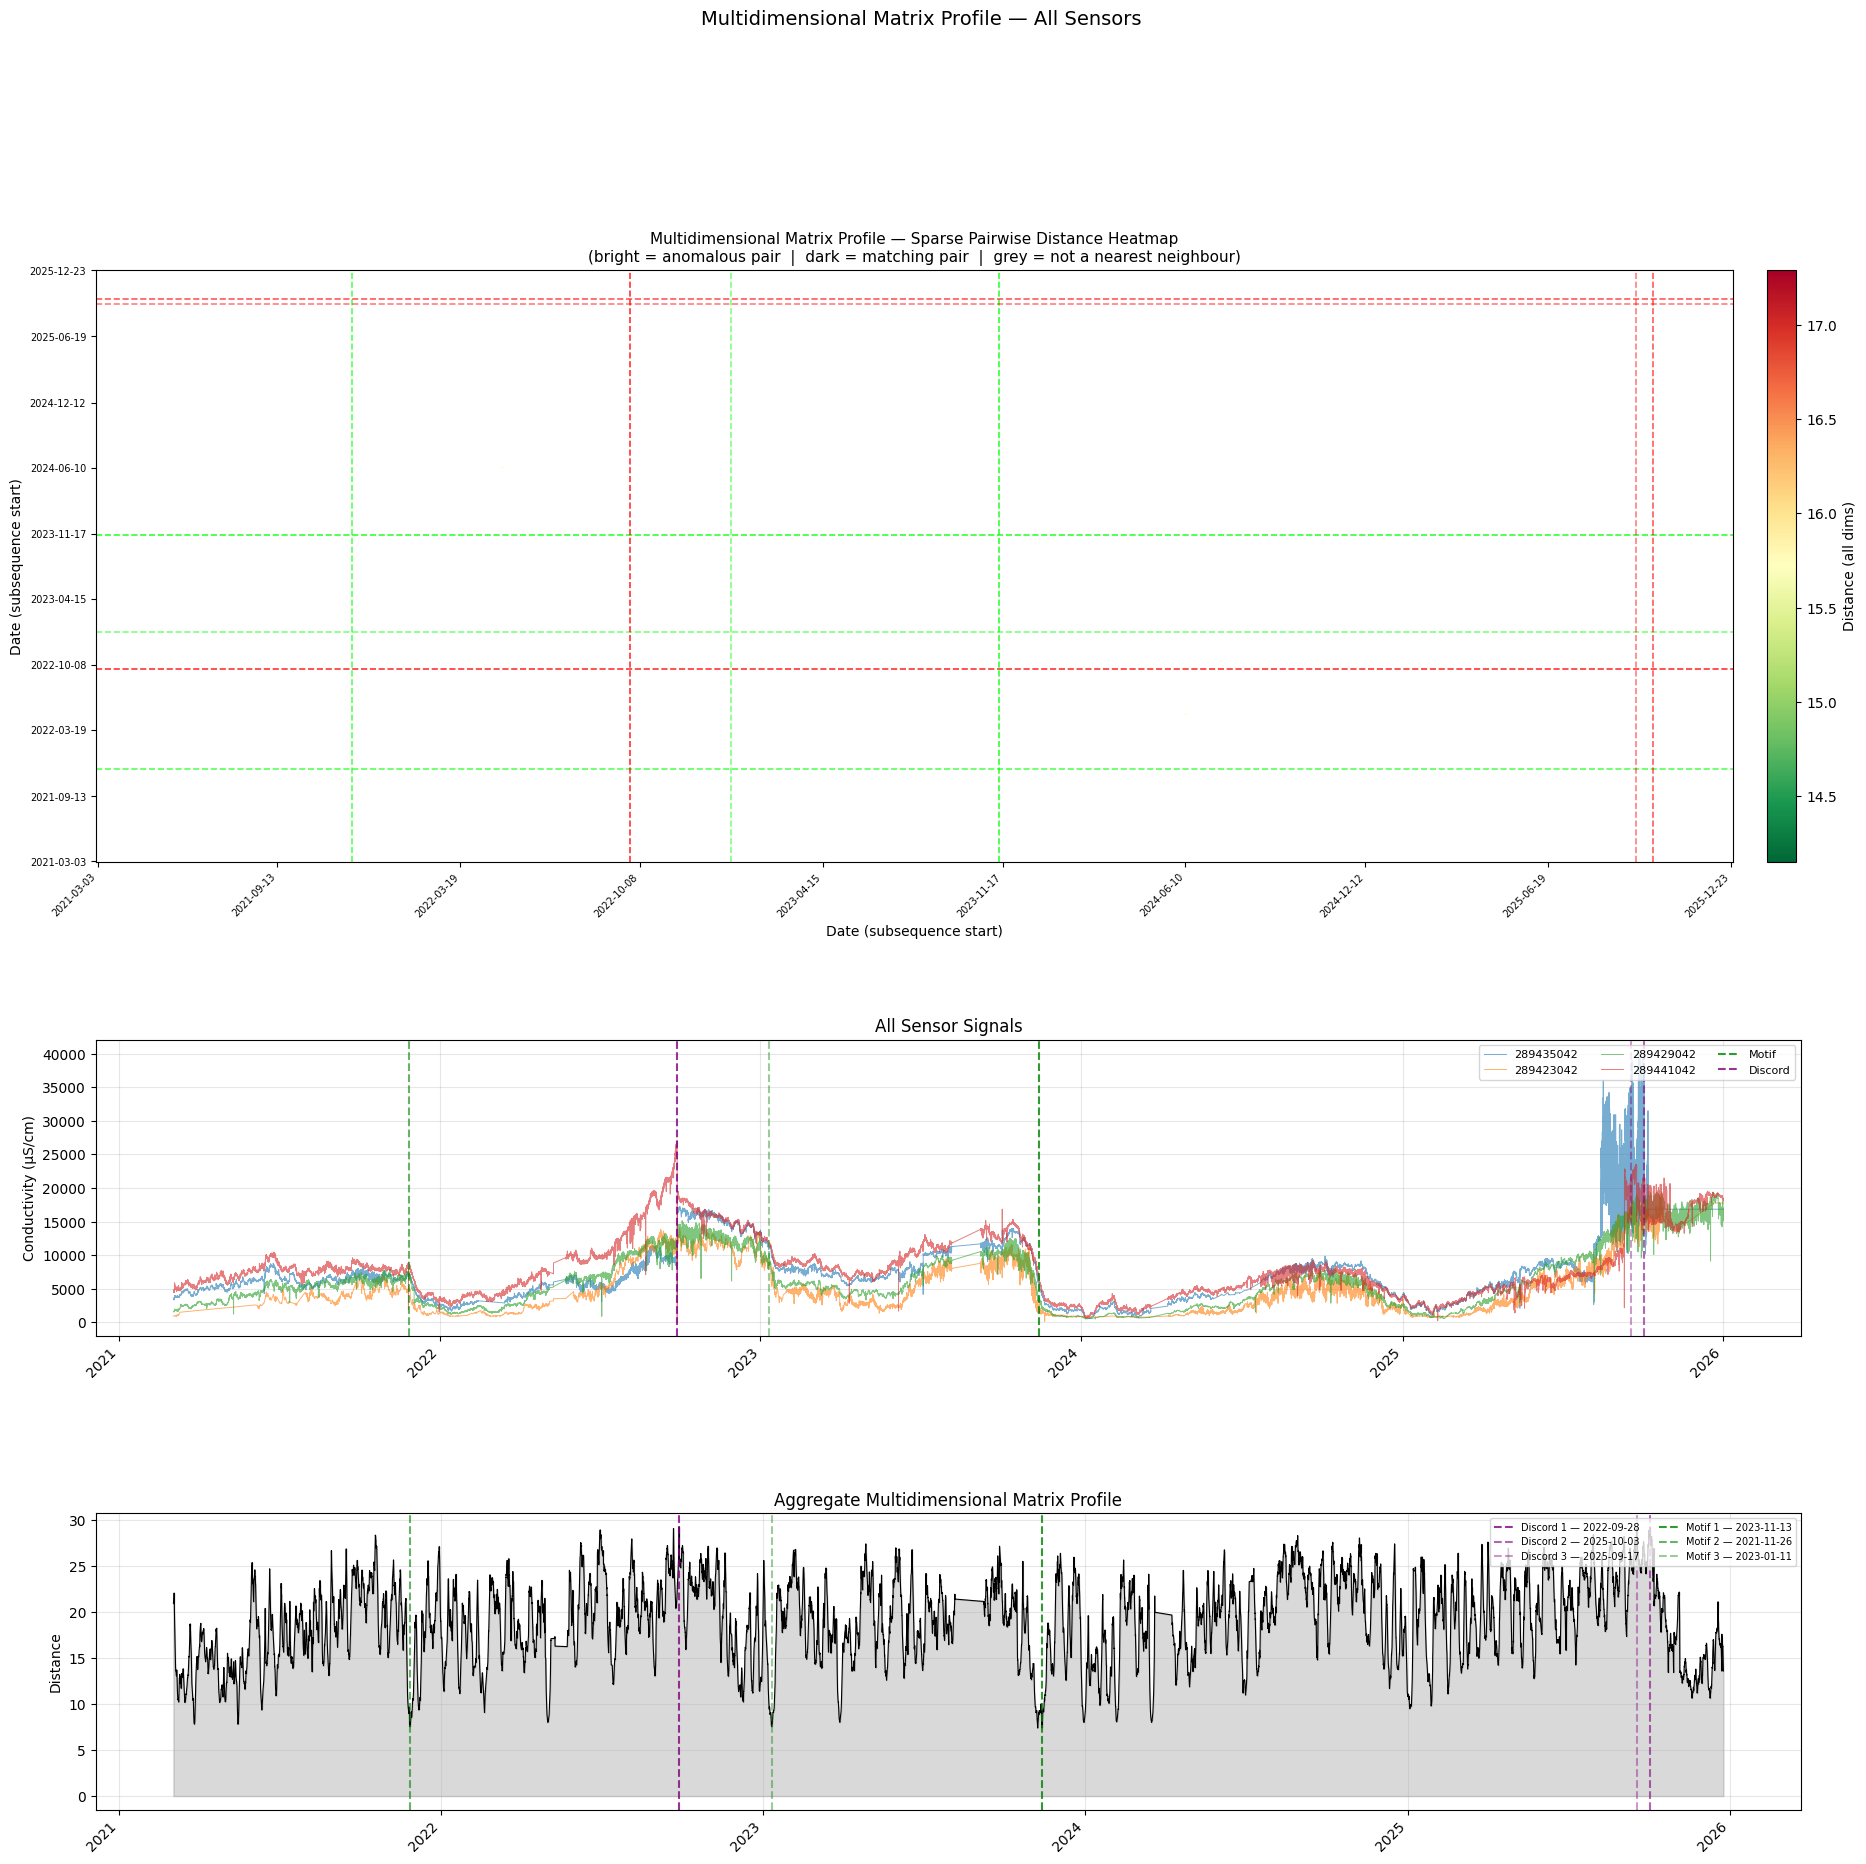

=== Top Discords — Contributing Sensors ===
  Discord #1 @ 2022-09-28 06:45 | MP=29.243 | driven by sensor 289435042
  Discord #2 @ 2025-10-03 00:30 | MP=29.164 | driven by sensor 289435042
  Discord #3 @ 2025-09-17 20:15 | MP=29.049 | driven by sensor 289435042


In [30]:
# ── 6. Visualization ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 20))
gs  = fig.add_gridspec(3, 2, height_ratios=[2, 1, 1], hspace=0.45, wspace=0.3)

# ── Panel A: Heatmap (both axes = dates) ─────────────────────────────────────
ax_heat = fig.add_subplot(gs[0, :])

im = ax_heat.imshow(ds, aspect='auto', cmap='RdYlGn_r',
                    origin='lower', interpolation='nearest')

# Map sampled positions → real dates
n_ticks = 10
tick_pos  = np.linspace(0, len(sample_idx) - 1, n_ticks, dtype=int)
tick_dates = [time_index[sample_idx[p]].strftime('%Y-%m-%d')
              for p in tick_pos if sample_idx[p] < len(time_index)]

ax_heat.set_xticks(tick_pos[:len(tick_dates)])
ax_heat.set_xticklabels(tick_dates, rotation=45, ha='right', fontsize=7)
ax_heat.set_yticks(tick_pos[:len(tick_dates)])
ax_heat.set_yticklabels(tick_dates, fontsize=7)
ax_heat.set_title('Multidimensional Matrix Profile — Sparse Pairwise Distance Heatmap\n'
                  '(bright = anomalous pair  |  dark = matching pair  |  grey = not a nearest neighbour)',
                  fontsize=11)
ax_heat.set_xlabel('Date (subsequence start)')
ax_heat.set_ylabel('Date (subsequence start)')
plt.colorbar(im, ax=ax_heat, fraction=0.02, pad=0.02, label='Distance (all dims)')

# Overlay motif / discord lines on heatmap
for i, idx in enumerate(motifs):
    ds_idx = int(np.searchsorted(sample_idx, idx))
    ax_heat.axvline(ds_idx, color='lime',   linestyle='--', alpha=0.8 - i*0.15, linewidth=1.2)
    ax_heat.axhline(ds_idx, color='lime',   linestyle='--', alpha=0.8 - i*0.15, linewidth=1.2)
for i, idx in enumerate(discords):
    ds_idx = int(np.searchsorted(sample_idx, idx))
    ax_heat.axvline(ds_idx, color='red',    linestyle='--', alpha=0.8 - i*0.15, linewidth=1.2)
    ax_heat.axhline(ds_idx, color='red',    linestyle='--', alpha=0.8 - i*0.15, linewidth=1.2)

# ── Panel B: Per-sensor signals ───────────────────────────────────────────────
ax_sig = fig.add_subplot(gs[1, :])
colors_sensor = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for s, col in zip(sensors, colors_sensor):
    ax_sig.plot(time_index, final_df[s].interpolate().values,
                label=s, color=col, alpha=0.6, linewidth=0.7)
for i, idx in enumerate(motifs):
    ax_sig.axvline(time_index[idx], color='green',  linestyle='--',
                   alpha=0.8 - i*0.2, label='Motif'   if i == 0 else None)
for i, idx in enumerate(discords):
    ax_sig.axvline(time_index[idx], color='purple', linestyle='--',
                   alpha=0.8 - i*0.2, label='Discord' if i == 0 else None)
ax_sig.set_title('All Sensor Signals')
ax_sig.set_ylabel('Conductivity (μS/cm)')
ax_sig.legend(loc='upper right', fontsize=8, ncol=3)
ax_sig.grid(True, alpha=0.3)
plt.setp(ax_sig.get_xticklabels(), rotation=45, ha='right')

# ── Panel C: Aggregate matrix profile ─────────────────────────────────────────
ax_mp = fig.add_subplot(gs[2, :])
ax_mp.plot(time_index[:len(aggregate_profile)], aggregate_profile,
           color='black', linewidth=0.8)
ax_mp.fill_between(time_index[:len(aggregate_profile)], aggregate_profile,
                   alpha=0.15, color='black')
for i, idx in enumerate(discords):
    ax_mp.axvline(time_index[idx], color='purple', linestyle='--', alpha=0.8 - i*0.2,
                  label=f'Discord {i+1} — {time_index[idx].strftime("%Y-%m-%d")}')
for i, idx in enumerate(motifs):
    ax_mp.axvline(time_index[idx], color='green',  linestyle='--', alpha=0.8 - i*0.2,
                  label=f'Motif {i+1} — {time_index[idx].strftime("%Y-%m-%d")}')
ax_mp.set_title('Aggregate Multidimensional Matrix Profile')
ax_mp.set_ylabel('Distance')
ax_mp.legend(loc='upper right', fontsize=7, ncol=2)
ax_mp.grid(True, alpha=0.3)
plt.setp(ax_mp.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Multidimensional Matrix Profile — All Sensors', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── 7. Contributing sensor report ─────────────────────────────────────────────
print("=== Top Discords — Contributing Sensors ===")
for rank, idx in enumerate(discords):
    dim_distances = mmp[:, idx]
    worst_dim     = int(np.argmax(np.diff(dim_distances)))
    ts = time_index[idx].strftime('%Y-%m-%d %H:%M')
    print(f"  Discord #{rank+1} @ {ts} | MP={aggregate_profile[idx]:.3f} "
          f"| driven by sensor {sensors[worst_dim]}")
